# Model comparison (bank churn)

Loads every serialized scikit-learn model found in the repository `models/` folder, runs predictions on the preprocessed test split (`data/`), and compares accuracy, precision, recall, F1, and ROC-AUC.

**Before running:** save trained estimators (or pipelines) with `joblib.dump(model, "../models/your_model.joblib")` from the other notebooks so they appear in `models/`.

In [10]:
from __future__ import annotations

import pickle
import warnings
from pathlib import Path

import joblib
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator
from sklearn.metrics import (
    RocCurveDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

warnings.filterwarnings("ignore", category=UserWarning)

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
def resolve_repo_paths() -> tuple[Path, Path, Path]:
    """Return (repo_root, data_dir, models_dir). Works from `notebooks/` or repo root."""
    colab_data = Path("/content/drive/MyDrive/bank-churn-dataset/data")
    candidates = [
        Path(".").resolve(),
        Path("..").resolve(),
        Path("../bank-churn-ml-classification").resolve(),
    ]
    if colab_data.joinpath("x_train.csv").exists():
        root = colab_data.parent
        return root, colab_data, root / "models"
    for root in candidates:
        data = root / "data"
        if (data / "x_train.csv").exists() or (data / "X_train.csv").exists():
            return root, data, root / "models"
    raise FileNotFoundError(
        "Could not find data/x_train.csv. Run this notebook from `notebooks/` or the repo root, "
        "or mount Colab paths to match other project notebooks."
    )


REPO_ROOT, DATA_DIR, MODELS_DIR = resolve_repo_paths()
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("REPO_ROOT:", REPO_ROOT)
print("DATA_DIR:", DATA_DIR)
print("MODELS_DIR:", MODELS_DIR)

REPO_ROOT: /content/drive/MyDrive/bank-churn-dataset
DATA_DIR: /content/drive/MyDrive/bank-churn-dataset/data
MODELS_DIR: /content/drive/MyDrive/bank-churn-dataset/models


In [13]:
def read_features(data_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    def pick(*names: str) -> Path:
        for n in names:
            p = data_dir / n
            if p.exists():
                return p
        raise FileNotFoundError(f"None of {names} found under {data_dir}")

    x_train_path = pick("x_train.csv", "X_train.csv")
    x_test_path = pick("x_test.csv", "X_test.csv")
    X_train = pd.read_csv(x_train_path)
    X_test = pd.read_csv(x_test_path)
    return X_train, X_test


def read_target(data_dir: Path) -> tuple[pd.Series, pd.Series]:
    y_train = pd.read_csv(data_dir / "y_train.csv").squeeze("columns")
    y_test = pd.read_csv(data_dir / "y_test.csv").squeeze("columns")
    return y_train, y_test


X_train, X_test = read_features(DATA_DIR)
y_train, y_test = read_target(DATA_DIR)

y_test = y_test.astype(int)
print("X_test shape:", X_test.shape, "| y_test:", y_test.shape)
print("Positive rate (test):", f"{y_test.mean():.3f}")

X_test shape: (2000, 12) | y_test: (2000,)
Positive rate (test): 0.203


In [14]:
def list_model_files(models_dir: Path) -> list[Path]:
    files: list[Path] = []
    for pattern in ("*.joblib", "*.pkl", "*.pickle"):
        files.extend(sorted(models_dir.glob(pattern)))
    # de-duplicate if multiple patterns match same file
    seen: set[Path] = set()
    out: list[Path] = []
    for p in files:
        rp = p.resolve()
        if rp not in seen:
            seen.add(rp)
            out.append(p)
    return out


def load_sklearn_object(path: Path):
    try:
        return joblib.load(path)
    except Exception:
        with path.open("rb") as f:
            return pickle.load(f)


def is_estimator(obj) -> bool:
    return isinstance(obj, BaseEstimator) and (
        hasattr(obj, "predict") or hasattr(obj, "predict_proba")
    )


model_paths = list_model_files(MODELS_DIR)
print(f"Found {len(model_paths)} model file(s) in {MODELS_DIR}")
for p in model_paths:
    print(" -", p.name)

Found 4 model file(s) in /content/drive/MyDrive/bank-churn-dataset/models
 - decision_tree_model.joblib
 - knn_model.joblib
 - logistic_regression_model.joblib
 - rf_churn_model.joblib


In [15]:
def evaluate_estimator(name: str, est, X: pd.DataFrame, y: pd.Series) -> dict:
    row: dict = {"model": name}
    if not hasattr(est, "predict"):
        row["error"] = "object has no predict()"
        return row
    try:
        y_pred = est.predict(X)
    except Exception as e:
        row["error"] = repr(e)
        return row

    y_pred = np.asarray(y_pred).astype(int)
    y_true = np.asarray(y).astype(int)

    row["accuracy"] = accuracy_score(y_true, y_pred)
    row["precision"] = precision_score(y_true, y_pred, zero_division=0)
    row["recall"] = recall_score(y_true, y_pred, zero_division=0)
    row["f1"] = f1_score(y_true, y_pred, zero_division=0)

    if hasattr(est, "predict_proba"):
        proba = est.predict_proba(X)
        if proba.ndim == 2 and proba.shape[1] >= 2:
            scores = proba[:, 1]
        else:
            scores = proba.ravel()
        row["roc_auc"] = roc_auc_score(y_true, scores)
    elif hasattr(est, "decision_function"):
        row["roc_auc"] = roc_auc_score(y_true, est.decision_function(X))
    else:
        row["roc_auc"] = np.nan

    return row


rows: list[dict] = []
loaded: list[tuple[str, object]] = []

if not model_paths:
    print(
        "No model files to load. Export models to ../models/ (e.g. joblib.dump(clf, '../models/logistic_regression.joblib'))."
    )
else:
    for path in model_paths:
        label = path.stem
        try:
            obj = load_sklearn_object(path)
        except Exception as e:
            rows.append({"model": label, "error": f"load failed: {e!r}"})
            continue

        if is_estimator(obj):
            loaded.append((label, obj))
            rows.append(evaluate_estimator(label, obj, X_test, y_test))
        elif isinstance(obj, dict) and "model" in obj and is_estimator(obj["model"]):
            est = obj["model"]
            loaded.append((label, est))
            rows.append(evaluate_estimator(label, est, X_test, y_test))
        else:
            rows.append(
                {
                    "model": label,
                    "error": "loaded object is not a sklearn estimator (expected predict / predict_proba)",
                }
            )

results = pd.DataFrame(rows)
display(results)

,model,accuracy,precision,recall,f1,roc_auc
0,decision_tree_model,0.8555,0.710714,0.488943,0.579330,0.824620
1,knn_model,0.8330,0.762590,0.260442,0.388278,0.810513
2,logistic_regression_model,0.7135,0.387228,0.700246,0.498688,0.777095
3,rf_churn_model,0.8570,0.689655,0.540541,0.606061,0.857259


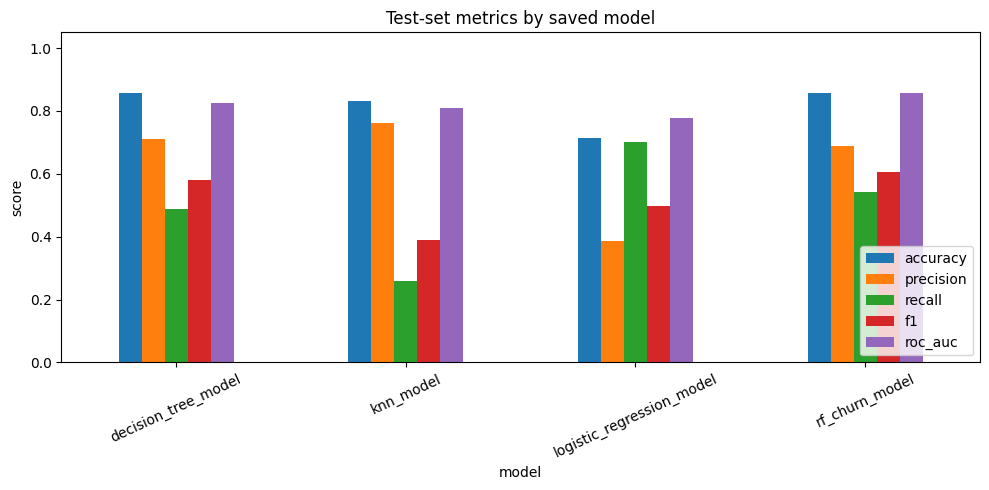

In [16]:
metric_cols = [c for c in ("accuracy", "precision", "recall", "f1", "roc_auc") if c in results.columns]
plot_df = results.drop(columns=["error"], errors="ignore").dropna(subset=metric_cols, how="all")

if plot_df.empty or not metric_cols:
    print("Nothing to plot yet — add valid estimators under models/.")
else:
    plot_df = plot_df.set_index("model")[metric_cols]
    ax = plot_df.plot(kind="bar", figsize=(10, 5), rot=25)
    ax.set_ylabel("score")
    ax.set_title("Test-set metrics by saved model")
    ax.legend(loc="lower right")
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

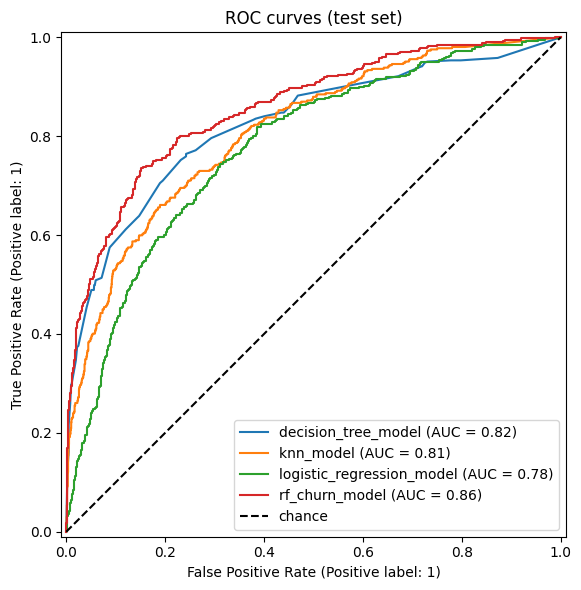

In [17]:
# Overlay ROC curves for estimators that support predict_proba or decision_function
fig, ax = plt.subplots(figsize=(7, 6))
plotted = 0
for label, est in loaded:
    try:
        if hasattr(est, "predict_proba"):
            RocCurveDisplay.from_estimator(est, X_test, y_test, ax=ax, name=label)
            plotted += 1
        elif hasattr(est, "decision_function"):
            RocCurveDisplay.from_estimator(est, X_test, y_test, ax=ax, name=label)
            plotted += 1
    except Exception as e:
        print(f"Skip ROC for {label}: {e}")

if plotted:
    ax.plot([0, 1], [0, 1], "k--", label="chance")
    ax.set_title("ROC curves (test set)")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
else:
    plt.close(fig)
    print("No ROC overlay (no loaded models with predict_proba / decision_function).")

In [18]:
best_model = results.sort_values(by='roc_auc', ascending=False).iloc[0]
print("The best performing model based on ROC-AUC is:")
display(best_model.to_frame().T)

The best performing model based on ROC-AUC is:


,model,accuracy,precision,recall,f1,roc_auc
3,rf_churn_model,0.857,0.689655,0.540541,0.606061,0.857259
